# CDS Pricing: Approximation vs Full Formula

**Purpose:** Validate the three CDS par-spread implementations from formula-sheet §10:
1. Constant-hazard approximation: $C \approx (1-R)\lambda$
2. Numerical integration formula (`cds_par_spread`)
3. Exact closed-form under constant hazard (`cds_par_spread_constant_full_closed_form`)

All fixtures match course landmarks: $\lambda=3\%$, $R=40\%$ → approx spread = 180 bps.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from src.credit.cds import (
    cds_par_spread_constant_hazard,
    cds_par_spread,
    cds_par_spread_constant_full_closed_form,
)
print('Imports OK')

Imports OK


## Section 1 — Setup

In [2]:
r    = 0.05
lam  = 0.03
R    = 0.40
T    = 5.0
freq = 1   # annual premium payments

print(f'CDS parameters: r={r}, lambda={lam}, R={R}, T={T}, freq={freq} (annual)')

CDS parameters: r=0.05, lambda=0.03, R=0.4, T=5.0, freq=1 (annual)


## Section 2 — Constant-Hazard Approximation

$$C \approx (1-R)\lambda$$
This ignores discounting and timing of the protection leg. For $\lambda=3\%$, $R=40\%$: $C \approx 0.6 \times 0.03 = 0.018 = 180$ bps.

In [3]:
approx = cds_par_spread_constant_hazard(lam, R)
print(f'Approximation spread: {approx * 10000:.2f} bps  (expected 180.00 bps)')
print(f'As decimal: {approx:.6f}')

Approximation spread: 180.00 bps  (expected 180.00 bps)
As decimal: 0.018000


## Section 3 — Full Numerical Formula (`cds_par_spread`)

In [4]:
payment_times = list(np.arange(1.0, T + 0.5, 1.0 / freq))
hazards_flat  = [lam] * len(payment_times)

full = cds_par_spread(payment_times, hazards_flat, r=r, R=R, accrual=True)
print(f'Full (numerical) spread T=5: {full * 10000:.4f} bps  (expected ≈ 184.55 bps)')
print(f'Payment times: {payment_times}')

Full (numerical) spread T=5: 184.5521 bps  (expected ≈ 184.55 bps)
Payment times: [1.0, 2.0, 3.0, 4.0, 5.0]


## Section 4 — Closed-Form Benchmark

In [5]:
cf = cds_par_spread_constant_full_closed_form(T=5.0, freq=1.0, r=r, lam=lam, R=R, accrual=True)
print(f'Closed-form spread T=5: {cf * 10000:.4f} bps')
print()
print('Note: approx (180.00 bps) != full formula (≈ 184.55 bps).')
print('The difference arises because the approximation ignores discounting of')
print('the protection and premium legs and the accrual-at-default term.')

Closed-form spread T=5: 184.5523 bps

Note: approx (180.00 bps) != full formula (≈ 184.55 bps).
The difference arises because the approximation ignores discounting of
the protection and premium legs and the accrual-at-default term.


## Section 5 — T=5 and T=10 Comparison

In [6]:
print(f"{'Method':<40} {'T=5 (bps)':>12} {'T=10 (bps)':>12}")
print('-' * 66)

for T_val in [5.0, 10.0]:
    pt = list(np.arange(1.0, T_val + 0.5, 1.0 / freq))
    hz = [lam] * len(pt)
    f_val = cds_par_spread(pt, hz, r=r, R=R, accrual=True)
    cf_val = cds_par_spread_constant_full_closed_form(T=T_val, freq=1.0, r=r, lam=lam, R=R, accrual=True)
    approx_val = cds_par_spread_constant_hazard(lam, R)
    if T_val == 5.0:
        row_full5, row_cf5, row_approx5 = f_val * 1e4, cf_val * 1e4, approx_val * 1e4
    else:
        row_full10, row_cf10, row_approx10 = f_val * 1e4, cf_val * 1e4, approx_val * 1e4

rows = [
    ('Approximation (1-R)*lambda',            row_approx5, row_approx10),
    ('Numerical full formula',                row_full5,   row_full10),
    ('Exact closed-form',                     row_cf5,     row_cf10),
]
for name, v5, v10 in rows:
    print(f'{name:<40} {v5:>12.4f} {v10:>12.4f}')

Method                                      T=5 (bps)   T=10 (bps)
------------------------------------------------------------------
Approximation (1-R)*lambda                   180.0000     180.0000
Numerical full formula                       184.5521     184.5521
Exact closed-form                            184.5523     184.5523


## Section 6 — Sensitivity Plots

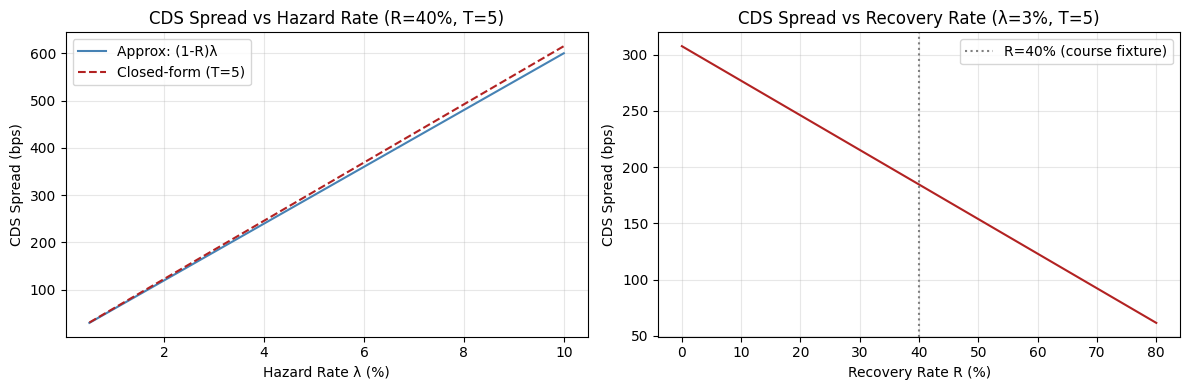

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# (a) Spread vs hazard rate
lam_vals = np.linspace(0.005, 0.10, 80)
approx_spreads = [cds_par_spread_constant_hazard(l, R) * 1e4 for l in lam_vals]
full_spreads   = [
    cds_par_spread_constant_full_closed_form(T=5.0, freq=1.0, r=r, lam=l, R=R, accrual=True) * 1e4
    for l in lam_vals
]

ax1.plot(lam_vals * 100, approx_spreads, label='Approx: (1-R)λ', color='steelblue')
ax1.plot(lam_vals * 100, full_spreads,   label='Closed-form (T=5)', color='firebrick', linestyle='--')
ax1.set_xlabel('Hazard Rate λ (%)')
ax1.set_ylabel('CDS Spread (bps)')
ax1.set_title('CDS Spread vs Hazard Rate (R=40%, T=5)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# (b) Spread vs recovery rate
R_vals = np.linspace(0.0, 0.80, 80)
full_r_spreads = [
    cds_par_spread_constant_full_closed_form(T=5.0, freq=1.0, r=r, lam=lam, R=R_i, accrual=True) * 1e4
    for R_i in R_vals
]

ax2.plot(R_vals * 100, full_r_spreads, color='firebrick')
ax2.axvline(40, color='gray', linestyle=':', label='R=40% (course fixture)')
ax2.set_xlabel('Recovery Rate R (%)')
ax2.set_ylabel('CDS Spread (bps)')
ax2.set_title('CDS Spread vs Recovery Rate (λ=3%, T=5)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7 — Validation Table

| Function | Inputs | Expected (bps) | Notes |
|----------|--------|----------------|-------|
| `cds_par_spread_constant_hazard(0.03, 0.40)` | λ=3%, R=40% | 180.00 | Approx only |
| `cds_par_spread(...)` | T=5, annual, accrual | ≈ 184.55 | Numerical |
| `cds_par_spread_constant_full_closed_form(5, 1, 0.05, 0.03, 0.40)` | same | ≈ 184.55 | Exact |

**Key insight:** The approximation $C \approx (1-R)\lambda$ is clean and good for quick estimates but understates the true spread. The full formula accounts for:
1. Discounting of both legs at rate $r$
2. The accrued premium payment at time of default (mid-period approximation)
3. The exact timing of protection payments